In [1]:
import os
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader
from PIL import Image

In [2]:
SEED = 67
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs("artifacts/figures", exist_ok=True)

Device: cpu


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 102
EPOCHS = 30
LR_CNN = 1e-3
LR_FINETUNE = 1e-4
DATA_DIR = "./data"
NUM_WORKERS = 0

In [4]:
# Transforms (Part A)
transform_base = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

transform_aug = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

transform_resnet = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [5]:
# Load Flowers102 (official train / val / test splits)
train_ds_base = torchvision.datasets.Flowers102(
    DATA_DIR, split="train", download=True, transform=transform_base)
train_ds_aug = torchvision.datasets.Flowers102(
    DATA_DIR, split="train", download=True, transform=transform_aug)
train_ds_resnet = torchvision.datasets.Flowers102(
    DATA_DIR, split="train", download=True, transform=transform_resnet)
val_ds = torchvision.datasets.Flowers102(
    DATA_DIR, split="val", download=True, transform=transform_resnet)
test_ds = torchvision.datasets.Flowers102(
    DATA_DIR, split="test", download=True, transform=transform_resnet)

train_loader_base = DataLoader(train_ds_base, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_loader_aug = DataLoader(train_ds_aug, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_loader_resnet = DataLoader(train_ds_resnet, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train: {len(train_ds_base)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Train: 1020  Val: 1020  Test: 6149


Batch size: 32
x.shape = torch.Size([32, 3, 224, 224])  y.shape = torch.Size([32])
x dtype = torch.float32  y dtype = torch.int64
Label range: 0 .. 101


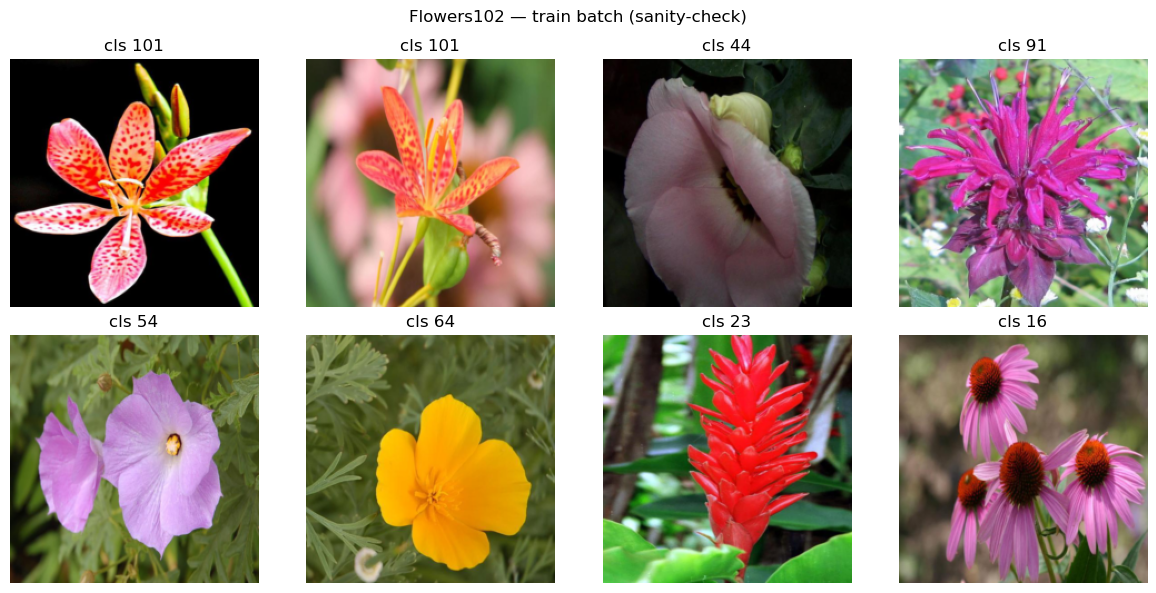

In [6]:
# Sanity-check

xb, yb = next(iter(train_loader_base))
print(f"Batch size: {BATCH_SIZE}")
print(f"x.shape = {xb.shape}  y.shape = {yb.shape}")
print(f"x dtype = {xb.dtype}  y dtype = {yb.dtype}")
print(f"Label range: {yb.min().item()} .. {yb.max().item()}")

mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    ax = axes[i // 4][i % 4]
    img = (xb[i].permute(1, 2, 0) * std + mean).clip(0, 1)
    ax.imshow(img)
    ax.set_title(f"cls {yb[i].item()}")
    ax.axis("off")
plt.suptitle("Flowers102 — train batch (sanity-check)")
plt.tight_layout()
plt.show()

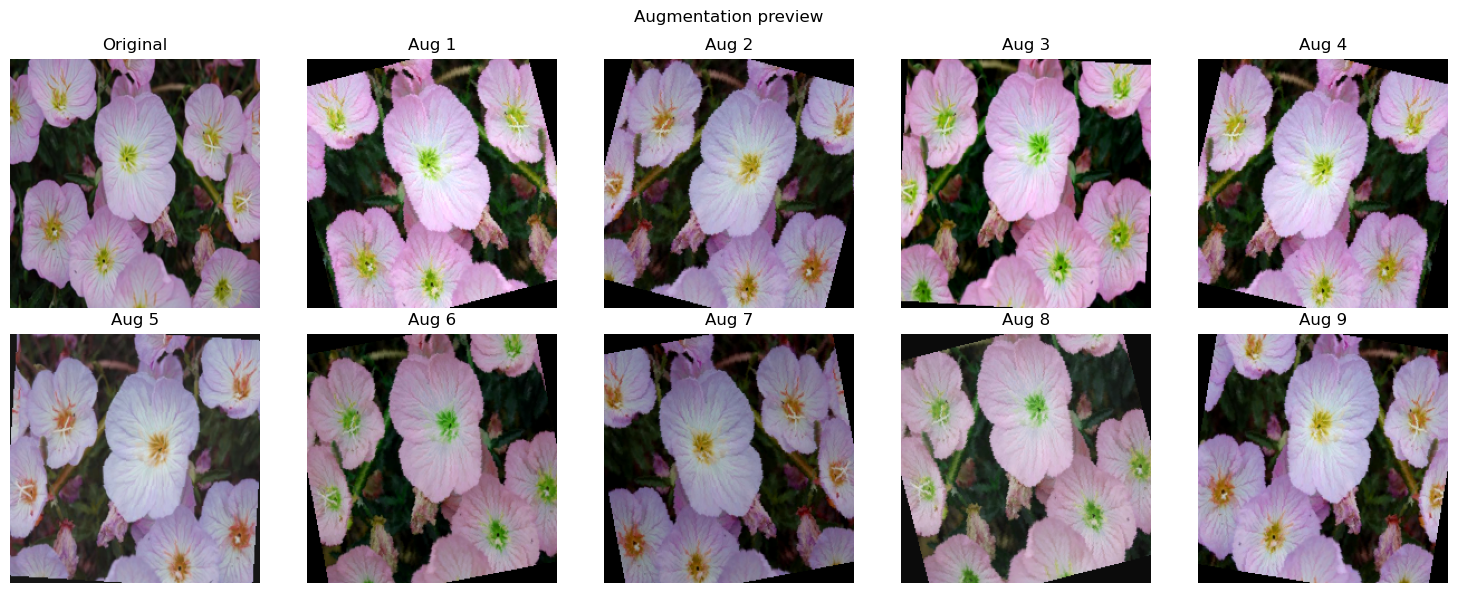

In [7]:
# Augmentation preview
raw_ds = torchvision.datasets.Flowers102(DATA_DIR, split="train", download=False)
img0, _ = raw_ds[0]
aug_vis = T.Compose([
    T.Resize((256, 256)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(0.2, 0.2, 0.2, 0.1),
])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0][0].imshow(img0.resize((IMG_SIZE, IMG_SIZE)))
axes[0][0].set_title("Original")
axes[0][0].axis("off")
for k in range(1, 10):
    ax = axes[k // 5][k % 5]
    ax.imshow(aug_vis(img0))
    ax.set_title(f"Aug {k}")
    ax.axis("off")
plt.suptitle("Augmentation preview")
plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png", dpi=100, bbox_inches="tight")
plt.show()

In [8]:
# SimpleCNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=102):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


In [9]:
# Training / evaluation helpers
def train_one_epoch(model, loader, criterion, optimizer, dev):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(dev), yb.to(dev)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return loss_sum / total, correct / total


def evaluate(model, loader, criterion, dev):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(dev), yb.to(dev)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss_sum += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    return loss_sum / total, correct / total


def run_experiment(model, train_ldr, val_ldr, lr, epochs, dev, tag):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc, best_sd = 0.0, None

    for ep in range(1, epochs + 1):
        tl, ta = train_one_epoch(model, train_ldr, criterion, optimizer, dev)
        vl, va = evaluate(model, val_ldr, criterion, dev)
        for k, v in zip(hist, [tl, vl, ta, va]):
            hist[k].append(v)
        if va > best_acc:
            best_acc = va
            best_sd = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0 or ep == 1:
            print(f"  [{tag}] ep {ep:2d}/{epochs}  "
                  f"train {tl:.4f}/{ta:.4f}  val {vl:.4f}/{va:.4f}")
    return hist, best_acc, best_sd

In [10]:
# C1: SimpleCNN, no augmentation
print("=== C1: simple-cnn-base ===")
model_c1 = SimpleCNN(NUM_CLASSES).to(device)
hist_c1, best_c1, sd_c1 = run_experiment(
    model_c1, train_loader_base, val_loader, LR_CNN, EPOCHS, device, "C1")
print(f"  best val acc = {best_c1:.4f}\n")


# C2: SimpleCNN, with augmentation
print("=== C2: simple-cnn-aug ===")
model_c2 = SimpleCNN(NUM_CLASSES).to(device)
hist_c2, best_c2, sd_c2 = run_experiment(
    model_c2, train_loader_aug, val_loader, LR_CNN, EPOCHS, device, "C2")
print(f"  best val acc = {best_c2:.4f}\n")


# C3: ResNet18 head-only
print("=== C3: resnet18-head-only ===")
net3 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in net3.parameters():
    p.requires_grad = False
net3.fc = nn.Linear(net3.fc.in_features, NUM_CLASSES)
model_c3 = net3.to(device)
hist_c3, best_c3, sd_c3 = run_experiment(
    model_c3, train_loader_resnet, val_loader, LR_CNN, EPOCHS, device, "C3")
print(f"  best val acc = {best_c3:.4f}\n")


# C4: ResNet18 fine-tune layer4 + fc
print("=== C4: resnet18-finetune ===")
net4 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in net4.parameters():
    p.requires_grad = False
for p in net4.layer4.parameters():
    p.requires_grad = True
net4.fc = nn.Linear(net4.fc.in_features, NUM_CLASSES)
model_c4 = net4.to(device)
hist_c4, best_c4, sd_c4 = run_experiment(
    model_c4, train_loader_resnet, val_loader, LR_FINETUNE, EPOCHS, device, "C4")
print(f"  best val acc = {best_c4:.4f}\n")


=== C1: simple-cnn-base ===
  [C1] ep  1/30  train 4.7876/0.0176  val 4.3080/0.0461
  [C1] ep  5/30  train 3.5286/0.1284  val 3.6605/0.1235
  [C1] ep 10/30  train 2.7675/0.2500  val 3.3523/0.1814
  [C1] ep 15/30  train 2.2842/0.3559  val 3.4396/0.2157
  [C1] ep 20/30  train 1.8176/0.4824  val 3.4698/0.2412
  [C1] ep 25/30  train 1.5915/0.5275  val 3.8343/0.2225
  [C1] ep 30/30  train 1.2956/0.6127  val 3.8755/0.2245
  best val acc = 0.2520

=== C2: simple-cnn-aug ===
  [C2] ep  1/30  train 4.7947/0.0186  val 4.3902/0.0373
  [C2] ep  5/30  train 3.9096/0.0725  val 3.5729/0.1206
  [C2] ep 10/30  train 3.4095/0.1529  val 3.2778/0.1833
  [C2] ep 15/30  train 3.0882/0.1853  val 3.1795/0.2000
  [C2] ep 20/30  train 2.8060/0.2431  val 2.8928/0.2755
  [C2] ep 25/30  train 2.7573/0.2520  val 2.9747/0.2676
  [C2] ep 30/30  train 2.6581/0.2912  val 2.9977/0.2716
  best val acc = 0.2912

=== C3: resnet18-head-only ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\U

100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:05<00:00, 7.88MB/s]


  [C3] ep  1/30  train 4.5551/0.0578  val 3.7897/0.2059
  [C3] ep  5/30  train 1.1047/0.9333  val 1.5070/0.7912
  [C3] ep 10/30  train 0.3389/0.9931  val 0.9553/0.8275
  [C3] ep 15/30  train 0.1641/0.9990  val 0.7845/0.8569
  [C3] ep 20/30  train 0.0983/1.0000  val 0.7069/0.8549
  [C3] ep 25/30  train 0.0646/1.0000  val 0.6667/0.8578
  [C3] ep 30/30  train 0.0437/1.0000  val 0.6374/0.8598
  best val acc = 0.8667

=== C4: resnet18-finetune ===
  [C4] ep  1/30  train 4.3025/0.1284  val 3.4311/0.4098
  [C4] ep  5/30  train 0.4925/0.9990  val 1.4125/0.8667
  [C4] ep 10/30  train 0.0837/1.0000  val 1.0186/0.8882
  [C4] ep 15/30  train 0.0351/1.0000  val 0.8970/0.8922
  [C4] ep 20/30  train 0.0216/1.0000  val 0.8228/0.8990
  [C4] ep 25/30  train 0.0150/1.0000  val 0.7760/0.9059
  [C4] ep 30/30  train 0.0101/1.0000  val 0.7524/0.9069
  best val acc = 0.9069



In [11]:
# Select best & test (один раз)
all_res = {
    "C1": {"val": best_c1, "sd": sd_c1, "hist": hist_c1, "arch": "SimpleCNN", "lr": LR_CNN},
    "C2": {"val": best_c2, "sd": sd_c2, "hist": hist_c2, "arch": "SimpleCNN", "lr": LR_CNN},
    "C3": {"val": best_c3, "sd": sd_c3, "hist": hist_c3, "arch": "ResNet18_head_only", "lr": LR_CNN},
    "C4": {"val": best_c4, "sd": sd_c4, "hist": hist_c4, "arch": "ResNet18_finetune_layer4_fc", "lr": LR_FINETUNE},
}
best_id = max(all_res, key=lambda k: all_res[k]["val"])
print(f"Best experiment: {best_id}  val_acc={all_res[best_id]['val']:.4f}")

if best_id in ("C1", "C2"):
    best_model = SimpleCNN(NUM_CLASSES)
else:
    best_model = models.resnet18(weights=None)
    best_model.fc = nn.Linear(best_model.fc.in_features, NUM_CLASSES)
best_model.load_state_dict(all_res[best_id]["sd"])
best_model.to(device)

_, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Test accuracy ({best_id}): {test_acc:.4f}")

Best experiment: C4  val_acc=0.9069
Test accuracy (C4): 0.8788


In [12]:
# Save best model + flat config
torch.save(all_res[best_id]["sd"], "artifacts/best_classifier.pt")

cfg = {
    "experiment_id": best_id,
    "dataset": "Flowers102",
    "num_classes": NUM_CLASSES,
    "architecture": all_res[best_id]["arch"],
    "input_size": IMG_SIZE,
    "optimizer": "Adam",
    "lr": all_res[best_id]["lr"],
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "seed": SEED,
    "loss": "CrossEntropyLoss",
    "best_val_accuracy": round(all_res[best_id]["val"], 4),
    "test_accuracy": round(test_acc, 4),
    "augmentations": (best_id == "C2"),
    "finetune_layers": "layer4+fc" if best_id == "C4" else ("fc_only" if best_id == "C3" else "none"),
    "transform": "Resize256_CenterCrop224_ToTensor_NormalizeImageNet" if best_id in ("C3", "C4") else "Resize224_ToTensor_NormalizeImageNet",
}
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(cfg, f, indent=2)
print("Saved best_classifier.pt + best_classifier_config.json")

Saved best_classifier.pt + best_classifier_config.json


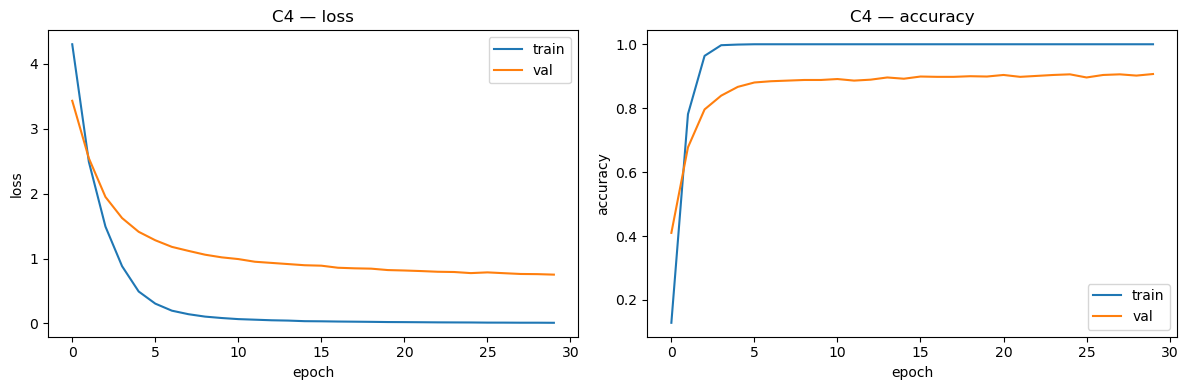

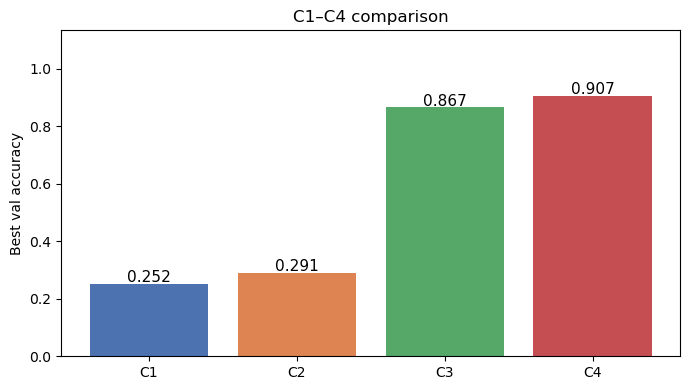

In [13]:
# Plot: training curves (best)
h = all_res[best_id]["hist"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(h["train_loss"], label="train")
a1.plot(h["val_loss"], label="val")
a1.set(xlabel="epoch", ylabel="loss", title=f"{best_id} — loss")
a1.legend()
a2.plot(h["train_acc"], label="train")
a2.plot(h["val_acc"], label="val")
a2.set(xlabel="epoch", ylabel="accuracy", title=f"{best_id} — accuracy")
a2.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/classification_curves_best.png", dpi=100, bbox_inches="tight")
plt.show()

# Plot: C1-C4 comparison
labels = ["C1", "C2", "C3", "C4"]
accs = [all_res[k]["val"] for k in labels]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, accs, color=["#4c72b0", "#dd8452", "#55a868", "#c44e52"])
for b, a in zip(bars, accs):
    ax.text(b.get_x() + b.get_width() / 2, a + 0.005, f"{a:.3f}", ha="center", fontsize=11)
ax.set_ylabel("Best val accuracy")
ax.set_title("C1–C4 comparison")
ax.set_ylim(0, max(accs) * 1.25)
plt.tight_layout()
plt.savefig("artifacts/figures/classification_compare.png", dpi=100, bbox_inches="tight")
plt.show()

Part B — OxfordIIITPet (segmentation)

Модель: DeepLabV3-ResNet50, предобученно на COCO (VOC labels).

Классы питомцев в VOC: **cat = 8**, **dog = 12**.

In [15]:
# Load OxfordIIITPet
pet_ds = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split="test", target_types="segmentation", download=True,
)
print(f"OxfordIIITPet test: {len(pet_ds)} images")

100%|███████████████████████████████████████████████████████████████████████████████| 792M/792M [06:42<00:00, 1.97MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 19.2M/19.2M [00:07<00:00, 2.64MB/s]


OxfordIIITPet test: 3669 images


Image type: <class 'PIL.Image.Image'>, size: (300, 225)
Mask type: <class 'PIL.PngImagePlugin.PngImageFile'>, size: (300, 225), unique values: [1 2 3]
Mask shape (as array): (225, 300)


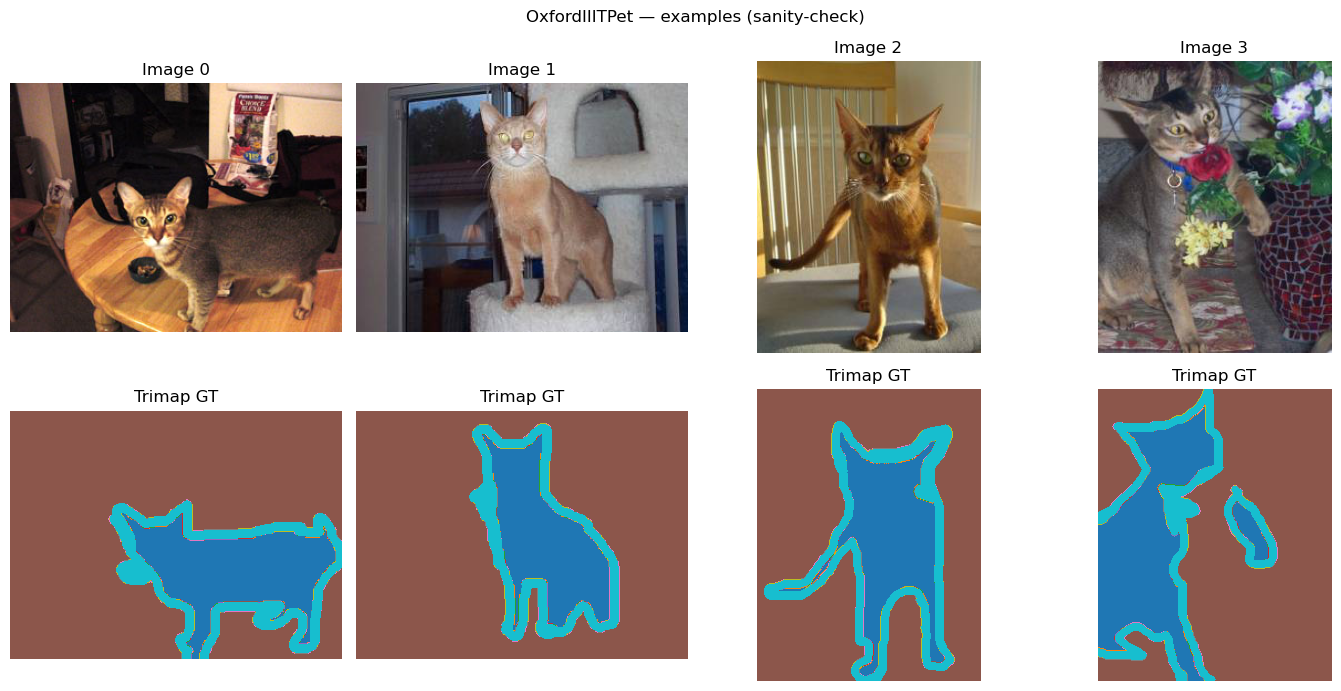

In [16]:
# Sanity-check Part B
img_sample, mask_sample = pet_ds[0]
print(f"Image type: {type(img_sample)}, size: {img_sample.size}")
mask_np = np.array(mask_sample)
print(f"Mask type: {type(mask_sample)}, size: {mask_sample.size}, "
      f"unique values: {np.unique(mask_np)}")
print(f"Mask shape (as array): {mask_np.shape}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    img, mask = pet_ds[i]
    axes[0][i].imshow(img)
    axes[0][i].set_title(f"Image {i}")
    axes[0][i].axis("off")
    axes[1][i].imshow(np.array(mask), cmap="tab10", vmin=1, vmax=3)
    axes[1][i].set_title("Trimap GT")
    axes[1][i].axis("off")
plt.suptitle("OxfordIIITPet — examples (sanity-check)")
plt.tight_layout()
plt.show()

In [17]:
# Pretrained segmentation model
seg_model = models.segmentation.deeplabv3_resnet50(
    weights=models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT
).to(device).eval()

seg_preprocess = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

CAT_CLS, DOG_CLS = 8, 12

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\Kirill/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100%|███████████████████████████████████████████████████████████████████████████████| 161M/161M [00:22<00:00, 7.51MB/s]


In [18]:
# Prediction & metric helpers
def predict_pet_mask(model, img_pil, preprocess, dev, mode="v1"):
    """
    V1 (mode='v1'): argmax по 21 классу → foreground = cat | dog.
    V2 (mode='v2'): softmax P(cat)+P(dog) > 0.5.
    """
    inp = preprocess(img_pil).unsqueeze(0).to(dev)
    with torch.no_grad():
        logits = model(inp)["out"]  # [1, 21, H, W]
    if mode == "v1":
        cls_map = logits.argmax(1).squeeze(0).cpu().numpy()
        return ((cls_map == CAT_CLS) | (cls_map == DOG_CLS)).astype(np.uint8)
    else:
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
        pet_prob = probs[CAT_CLS] + probs[DOG_CLS]
        return (pet_prob > 0.5).astype(np.uint8)


def seg_metrics(pred, gt):
    """IoU, pixel-precision, pixel-recall для бинарных масок."""
    p, g = pred.astype(bool), gt.astype(bool)
    inter = (p & g).sum()
    union = (p | g).sum()
    iou = inter / max(union, 1)
    prec = inter / max(p.sum(), 1)
    rec = inter / max(g.sum(), 1)
    return float(iou), float(prec), float(rec)


In [ ]:
# Evaluate V1 and V2
N_EVAL = 100
m_v1 = {"iou": [], "prec": [], "rec": []}
m_v2 = {"iou": [], "prec": [], "rec": []}

for i in range(N_EVAL):
    img_pil, mask_pil = pet_ds[i]
    gt = np.array(mask_pil.resize((256, 256), Image.NEAREST))
    gt_fg = (gt == 1).astype(np.uint8)  # trimap: 1=foreground

    p1 = predict_pet_mask(seg_model, img_pil, seg_preprocess, device, "v1")
    p2 = predict_pet_mask(seg_model, img_pil, seg_preprocess, device, "v2")

    i1, pr1, rc1 = seg_metrics(p1, gt_fg)
    i2, pr2, rc2 = seg_metrics(p2, gt_fg)
    for d, vals in [(m_v1, (i1, pr1, rc1)), (m_v2, (i2, pr2, rc2))]:
        d["iou"].append(vals[0])
        d["prec"].append(vals[1])
        d["rec"].append(vals[2])

mean_v1 = {k: float(np.mean(v)) for k, v in m_v1.items()}
mean_v2 = {k: float(np.mean(v)) for k, v in m_v2.items()}

print("V1 (argmax)  :", {k: f"{v:.4f}" for k, v in mean_v1.items()})
print("V2 (prob>0.5):", {k: f"{v:.4f}" for k, v in mean_v2.items()})

In [ ]:
# Segmentation visualisation
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for row in range(4):
    img_pil, mask_pil = pet_ds[row]
    gt = np.array(mask_pil.resize((256, 256), Image.NEAREST))
    gt_fg = (gt == 1).astype(np.uint8)
    p1 = predict_pet_mask(seg_model, img_pil, seg_preprocess, device, "v1")
    p2 = predict_pet_mask(seg_model, img_pil, seg_preprocess, device, "v2")

    axes[row][0].imshow(img_pil.resize((256, 256)))
    axes[row][0].set_title("Image")
    i1, _, _ = seg_metrics(p1, gt_fg)
    axes[row][1].imshow(gt_fg, cmap="gray")
    axes[row][1].set_title("GT")
    axes[row][2].imshow(p1, cmap="gray")
    axes[row][2].set_title(f"V1 IoU={i1:.2f}")
    i2, _, _ = seg_metrics(p2, gt_fg)
    axes[row][3].imshow(p2, cmap="gray")
    axes[row][3].set_title(f"V2 IoU={i2:.2f}")
    for c in range(4):
        axes[row][c].axis("off")

plt.suptitle("Segmentation: OxfordIIITPet (DeepLabV3)")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# Segmentation metrics bar chart
met_names = ["mean_iou", "pixel_precision", "pixel_recall"]
v1v = [mean_v1["iou"], mean_v1["prec"], mean_v1["rec"]]
v2v = [mean_v2["iou"], mean_v2["prec"], mean_v2["rec"]]

x = np.arange(len(met_names))
w = 0.3
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w / 2, v1v, w, label="V1 argmax", color="#4c72b0")
b2 = ax.bar(x + w / 2, v2v, w, label="V2 prob>0.5", color="#dd8452")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(met_names)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Segmentation metrics: V1 vs V2")
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# Save runs.csv
fields = [
    "experiment_id", "task", "dataset", "seed", "model_summary",
    "optimizer", "lr", "epochs_trained", "best_val_accuracy",
    "test_accuracy", "precision", "recall", "mean_iou", "notes",
]
rows = [
    dict(experiment_id="C1", task="classification", dataset="Flowers102",
         seed=SEED, model_summary="SimpleCNN 4conv+BN", optimizer="Adam",
         lr=LR_CNN, epochs_trained=EPOCHS, best_val_accuracy=round(best_c1, 4),
         test_accuracy=round(test_acc, 4) if best_id == "C1" else "",
         precision="", recall="", mean_iou="", notes="no augmentation"),
    dict(experiment_id="C2", task="classification", dataset="Flowers102",
         seed=SEED, model_summary="SimpleCNN 4conv+BN", optimizer="Adam",
         lr=LR_CNN, epochs_trained=EPOCHS, best_val_accuracy=round(best_c2, 4),
         test_accuracy=round(test_acc, 4) if best_id == "C2" else "",
         precision="", recall="", mean_iou="", notes="with augmentation"),
    dict(experiment_id="C3", task="classification", dataset="Flowers102",
         seed=SEED, model_summary="ResNet18 head-only", optimizer="Adam",
         lr=LR_CNN, epochs_trained=EPOCHS, best_val_accuracy=round(best_c3, 4),
         test_accuracy=round(test_acc, 4) if best_id == "C3" else "",
         precision="", recall="", mean_iou="", notes="backbone frozen"),
    dict(experiment_id="C4", task="classification", dataset="Flowers102",
         seed=SEED, model_summary="ResNet18 finetune layer4+fc", optimizer="Adam",
         lr=LR_FINETUNE, epochs_trained=EPOCHS, best_val_accuracy=round(best_c4, 4),
         test_accuracy=round(test_acc, 4) if best_id == "C4" else "",
         precision="", recall="", mean_iou="", notes="layer4+fc unfrozen"),
    dict(experiment_id="V1", task="segmentation", dataset="OxfordIIITPet",
         seed=SEED, model_summary="DeepLabV3_ResNet50 pretrained", optimizer="",
         lr="", epochs_trained="", best_val_accuracy="",
         test_accuracy="", precision=round(mean_v1["prec"], 4),
         recall=round(mean_v1["rec"], 4), mean_iou=round(mean_v1["iou"], 4),
         notes="argmax, foreground=cat|dog"),
    dict(experiment_id="V2", task="segmentation", dataset="OxfordIIITPet",
         seed=SEED, model_summary="DeepLabV3_ResNet50 pretrained", optimizer="",
         lr="", epochs_trained="", best_val_accuracy="",
         test_accuracy="", precision=round(mean_v2["prec"], 4),
         recall=round(mean_v2["rec"], 4), mean_iou=round(mean_v2["iou"], 4),
         notes="softmax prob(cat)+prob(dog)>0.5"),
]

with open("artifacts/runs.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=fields)
    w.writeheader()
    w.writerows(rows)
print("artifacts/runs.csv saved")

In [ ]:
# Итоговые результаты
print("+" * 60)
print("Part A — Flowers102 classification")
for eid in ("C1", "C2", "C3", "C4"):
    print(f"  {eid}: val_acc = {all_res[eid]['val']:.4f}")
print(f"  Best: {best_id} → test_acc = {test_acc:.4f}")
print()
print("Part B — OxfordIIITPet segmentation")
print(f"  V1 mean_IoU={mean_v1['iou']:.4f}  prec={mean_v1['prec']:.4f}  rec={mean_v1['rec']:.4f}")
print(f"  V2 mean_IoU={mean_v2['iou']:.4f}  prec={mean_v2['prec']:.4f}  rec={mean_v2['rec']:.4f}")
print("-" * 60)